In [ ]:
# File này sử dụng dữ liệu từ bộ dữ liệu CIC-IDS2017 để phát triển một mô hình Deep Learning nhằm phát hiện các cuộc tấn công mạng, 
# đặc biệt là Infiltration và Exfiltration. Dưới đây là phần cài đặt ban đầu, bao gồm việc nhập các thư viện cần thiết và cấu hình đường dẫn đến dữ liệu.
# File này sẽ sử dụng 2 file CSV đã được trích xuất từ các file pcap của CIC-IDS2017:
# - `Monday-WorkingHours.pcap_ISCX.csv`: Chứa các kết nối mạng diễn ra vào ngày thứ Hai trong giờ làm việc, chủ yếu là lưu lượng bình thường (benign).
# - `Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv`: Chứa các kết nối mạng diễn ra vào ngày thứ Năm vào buổi chiều, bao gồm các cuộc tấn công Infiltration.
# Link tải bộ dữ liệu: https://cicresearch.ca/CICDataset/CIC-IDS-2017/browse.php?p=CIC-IDS-2017%2FCSVs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import sys

# Các thư viện Deep Learning & Metrics
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

# ==========================================
# CẤU HÌNH ĐƯỜNG DẪN FILE (Sửa lại cho đúng máy bạn)
# ==========================================
TRAIN_PATH = 'Monday-WorkingHours.pcap_ISCX.csv'
TEST_PATH = 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'

# SELECTED_FEATURES = [
#     # --- Nhóm 1: Mẫu hình thời gian (Temporal) - Rất quan trọng để bắt Infiltration ---
#     'Flow Duration',       # Thời gian kết nối dài bất thường
#     'Flow IAT Mean',       # Khoảng cách giữa các gói tin
#     'Flow IAT Std',        # Độ biến động của khoảng cách (Jitter)
#     'Idle Mean',           # Thời gian ngủ (Attacker hay "ngủ" để trốn)

#     # --- Nhóm 2: Kích thước gói tin (Packet Size) - Phát hiện Exfiltration ---
#     'Fwd Packet Length Mean', 
#     'Bwd Packet Length Mean', 
#     'Packet Length Std',      # Sự thay đổi kích thước gói tin
#     'Avg Fwd Segment Size',   # (Tên chuẩn trong file CSV, thay cho Average Packet Size)

#     # --- Nhóm 3: Lưu lượng (Volume) ---
#     'Total Fwd Packets',
#     'Total Backward Packets',      # (Tên chuẩn trong file CSV)

#     # --- Nhóm 4: Hành vi (Behavioral) ---
#     'Flow Bytes/s',
#     'Down/Up Ratio',          # Tỷ lệ tải lên/tải xuống (Exfiltration thường có Up cao)

#     # --- Nhóm 5: Cờ hiệu (Flags) - Dấu hiệu Lateral Movement ---
#     'PSH Flag Count',         # Đẩy dữ liệu liên tục
#     'SYN Flag Count',         # Dấu hiệu scan port
#     'Fwd PSH Flags'           # Cờ PSH chiều đi
# ]

SELECTED_FEATURES = [
    'Flow Duration', 
    'Total Fwd Packets', 
    'Total Backward Packets', 
    'Fwd Packet Length Mean',
    'Bwd Packet Length Mean',
    'Flow Bytes/s',
    'Flow IAT Mean',
    'Flow IAT Std',
    'Fwd PSH Flags',
    'Packet Length Std',
    'SYN Flag Count',
    'PSH Flag Count',
    'Down/Up Ratio',
    'Avg Fwd Segment Size',
    'Idle Mean'
]


print("Setup hoàn tất. Thư viện đã sẵn sàng.")

Matplotlib is building the font cache; this may take a moment.


✅ Setup hoàn tất. Thư viện đã sẵn sàng.


In [ ]:
def load_data_optimized(filepath, features_list, has_label=False):
    """
    Hàm load dữ liệu tối ưu RAM và kiểm tra xem có bao nhiêu tấn công bị drop do lỗi data.
    """
    if not os.path.exists(filepath):
        print(f"Lỗi: Không tìm thấy file {filepath}")
        return None, None

    print(f"\n--- Đang xử lý file: {filepath} ---")
    
    df_header = pd.read_csv(filepath, nrows=0)
    orig_cols = df_header.columns.tolist()
    clean_map = {c: c.strip() for c in orig_cols} 
    
    
    use_cols_orig = [c for c in orig_cols if clean_map[c] in features_list]
    
    if has_label:
        label_col_orig = [c for c in orig_cols if clean_map[c] == 'Label'][0]
        use_cols_orig.append(label_col_orig)

    
    df = pd.read_csv(filepath, usecols=use_cols_orig)
    df.rename(columns=clean_map, inplace=True) 
    
    
    y = None
    if has_label:
        y_raw = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
        total_attacks_orig = y_raw.sum()
        print(f"📊 Tổng số mẫu tấn công ban đầu (trước khi clean): {total_attacks_orig}")

    
    initial_rows = len(df)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    if has_label:
        rows_with_nan = df[df.isna().any(axis=1)]
        attacks_dropped = 0
        if len(rows_with_nan) > 0:
            attacks_dropped = y_raw[rows_with_nan.index].sum()
            if attacks_dropped > 0:
                print(f"CẢNH BÁO: Có {attacks_dropped} mẫu tấn công chứa NaN/Inf và sẽ bị xóa!")
            else:
                print("An toàn: Không có mẫu tấn công nào bị lỗi dữ liệu.")
    
    df.dropna(inplace=True)
    print(f"Đã loại bỏ {initial_rows - len(df)} dòng lỗi (NaN/Inf).")
    
    if has_label:
        y = y_raw[df.index].values
        print(f"Số mẫu tấn công còn lại để test: {np.sum(y)}")
    
    return df, y

In [ ]:

df_train, _ = load_data_optimized(TRAIN_PATH, SELECTED_FEATURES, has_label=False)
df_test, y_test = load_data_optimized(TEST_PATH, SELECTED_FEATURES, has_label=True)

print("\n[INFO] Đang chuẩn hóa dữ liệu...")
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(df_train)
X_test_scaled = scaler.transform(df_test[SELECTED_FEATURES]) # Chỉ scale features, bỏ label ra

print(f"Shape Train: {X_train_scaled.shape}")
print(f"Shape Test : {X_test_scaled.shape}")


--- Đang xử lý file: Monday-WorkingHours.pcap_ISCX.csv ---
📉 Đã loại bỏ 437 dòng lỗi (NaN/Inf).

--- Đang xử lý file: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ---
📊 Tổng số mẫu tấn công ban đầu (trước khi clean): 36
✅ An toàn: Không có mẫu tấn công nào bị lỗi dữ liệu.
📉 Đã loại bỏ 207 dòng lỗi (NaN/Inf).
📊 Số mẫu tấn công còn lại để test: 36

[INFO] Đang chuẩn hóa dữ liệu...
✅ Shape Train: (529481, 15)
✅ Shape Test : (288395, 15)



[INFO] Bắt đầu Training...
Epoch 1/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0085 - val_loss: 4.9231e-05 - learning_rate: 0.0010
Epoch 2/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 1.3493e-04 - val_loss: 1.9777e-05 - learning_rate: 0.0010
Epoch 3/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 8.6677e-05 - val_loss: 1.4899e-05 - learning_rate: 0.0010
Epoch 4/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 6.9143e-05 - val_loss: 1.3146e-05 - learning_rate: 0.0010
Epoch 5/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 5.0178e-05 - val_loss: 9.5466e-06 - learning_rate: 2.0000e-04
Epoch 6/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 4.6743e-05 - val_loss: 9.0280e-06 - learning_rate: 2.0000e-04
Epoch 7/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 4.5136e-05 - val_loss: 8.5287e-06 - learning_rate: 2.0000e-04
Epoch 8/20
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 4.1426e-05 - val_loss: 8.0683e-06 - learning_rate: 4.0000

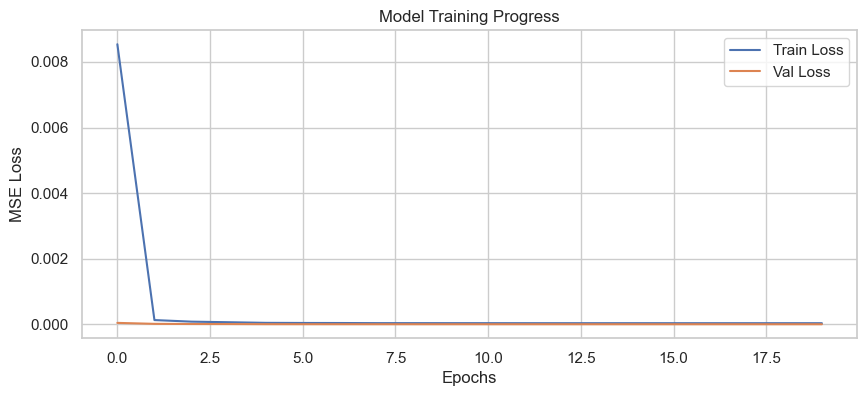

In [ ]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = BatchNormalization()(encoded)
    encoded = Dropout(0.1)(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded) # Latent Space

    # Decoder
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    decoded = BatchNormalization()(decoded)
    output_layer = Dense(input_dim, activation='sigmoid')(decoded)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mse')
    return model

autoencoder = build_autoencoder(X_train_scaled.shape[1])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

print("\n[INFO] Bắt đầu Training...")
history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=20, # 20 là đủ demo, thực tế có thể tăng lên 50
    batch_size=128,
    shuffle=True,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Training Progress')
plt.ylabel('MSE Loss')
plt.xlabel('Epochs')
plt.legend()
plt.show()

[INFO] Đang phân tích Reconstruction Error trên tập Test...
9013/9013 ━━━━━━━━━━━━━━━━━━━━ 6s 609us/step

📊 THỐNG KÊ SAI SỐ (MSE):
   - Benign Mean: 0.000132 | Max: 0.188851
   - Attack Mean: 0.000639 | Min: 0.000002

🎯 [CHIẾN LƯỢC] Aggressive Threshold được chọn: 0.00004895


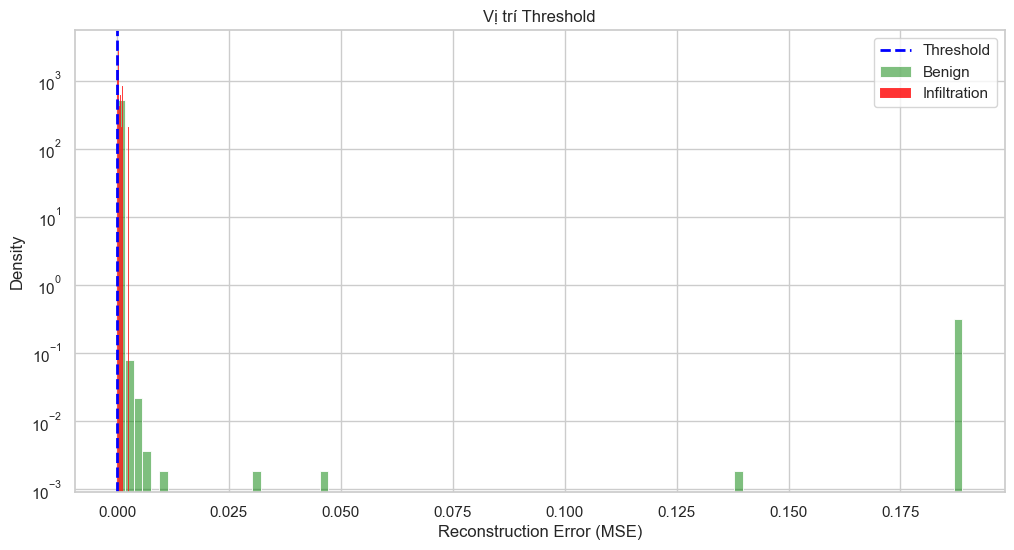

In [ ]:
print("Đang phân tích Reconstruction Error trên tập Test...")

test_preds = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - test_preds, 2), axis=1)

mse_attacks = mse_test[y_test == 1]
mse_benign = mse_test[y_test == 0]

CURRENT_THRESHOLD = np.percentile(mse_test, 94)

print(f"\nTHỐNG KÊ SAI SỐ (MSE):")
print(f"   - Benign Mean: {np.mean(mse_benign):.6f} | Max: {np.max(mse_benign):.6f}")
print(f"   - Attack Mean: {np.mean(mse_attacks):.6f} | Min: {np.min(mse_attacks):.6f}")


print(f"\n Aggressive Threshold được chọn: {CURRENT_THRESHOLD:.8f}")

plt.figure(figsize=(12, 6))
sns.histplot(mse_benign, bins=100, color='green', label='Benign', alpha=0.5, stat='density')
sns.histplot(mse_attacks, bins=20, color='red', label='Infiltration', alpha=0.8, stat='density')
plt.axvline(CURRENT_THRESHOLD, color='blue', linestyle='--', linewidth=2, label='Threshold')

plt.yscale('log')
plt.title('Vị trí Threshold')
plt.xlabel('Reconstruction Error (MSE)')
plt.legend()
plt.show()

In [ ]:

y_pred = (mse_test > CURRENT_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print(f"KẾT QUẢ ĐÁNH GIÁ (MAX RECALL)")
print("="*50)
print(f"Tấn công phát hiện đúng (TP): {tp}/{np.sum(y_test)}")
print(f"Tấn công bỏ sót (FN)       : {fn}")
print(f"Báo động giả (FP)          : {fp} (Số lượng Benign bị bắt nhầm)")
print("-" * 30)
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
print("="*50)



🏆 KẾT QUẢ ĐÁNH GIÁ (MAX RECALL)
✅ Tấn công phát hiện đúng (TP): 34/36
❌ Tấn công bỏ sót (FN)       : 2
⚠️ Báo động giả (FP)          : 17270 (Số lượng Benign bị bắt nhầm)
------------------------------
Recall    : 0.9444
Precision : 0.0020
F1-Score  : 0.0039


9013/9013 ━━━━━━━━━━━━━━━━━━━━ 5s 579us/step


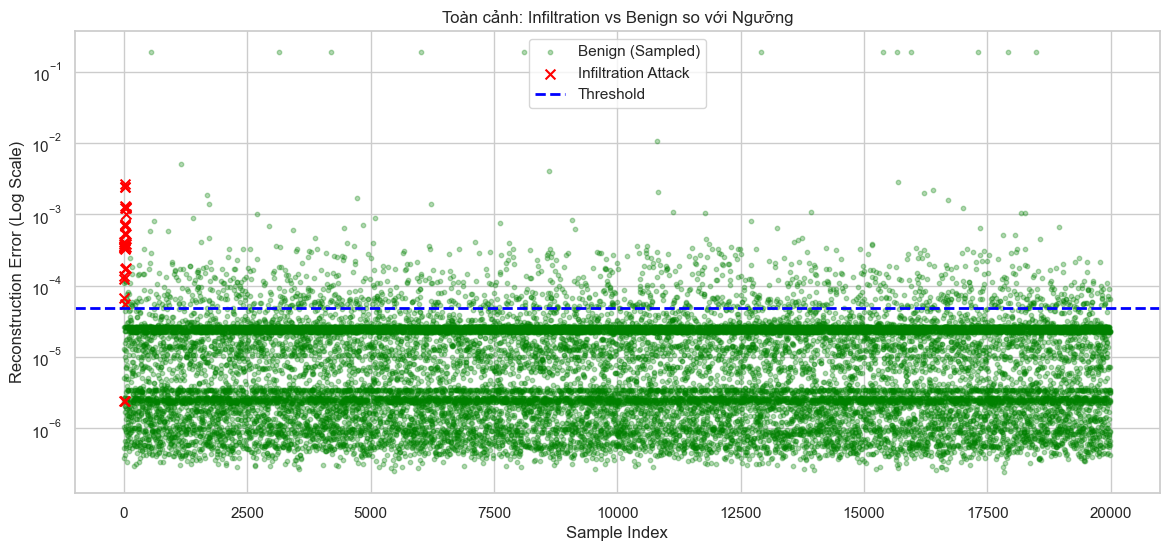

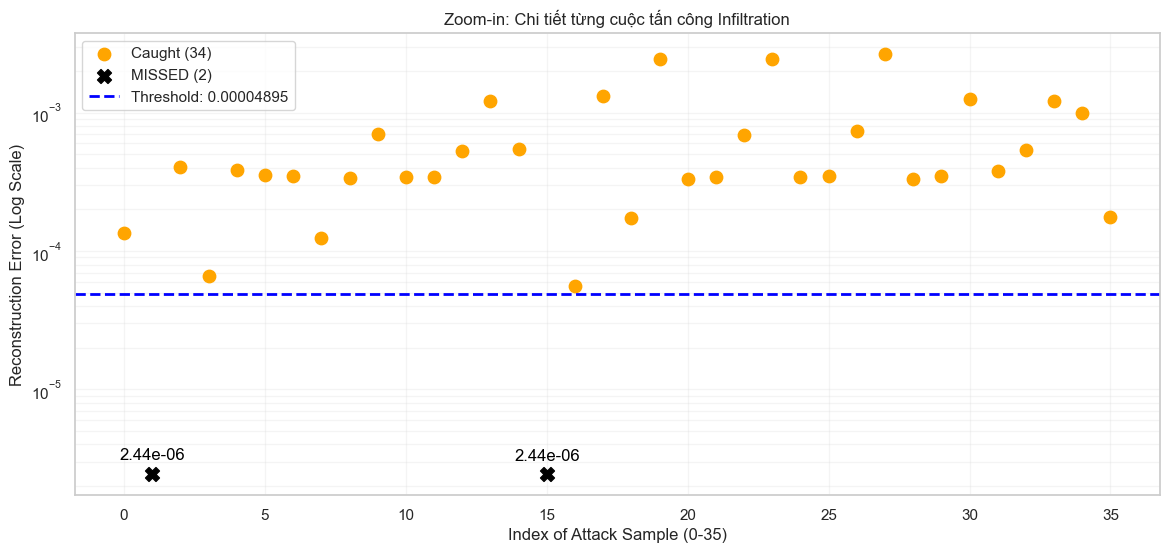

In [ ]:


# ==============================================================================
# CẤU HÌNH DỮ LIỆU ĐỂ VẼ
# ==============================================================================

# 2. Tính lại MSE (nếu cần)
test_preds = autoencoder.predict(X_test_scaled)
mse_test = np.mean(np.power(X_test_scaled - test_preds, 2), axis=1)

# 3. Tách dữ liệu
mse_benign = mse_test[y_test == 0]
mse_attack = mse_test[y_test == 1]

# Downsample Benign (vì 200k điểm quá nặng, chỉ lấy 2000 điểm để làm nền)
np.random.seed(42)
idx_benign_sample = np.random.choice(len(mse_benign), 20000, replace=False)
mse_benign_sample = mse_benign[idx_benign_sample]

# ==============================================================================
# BIỂU ĐỒ 1: TOÀN CẢNH (SCATTER PLOT)
# ==============================================================================
plt.figure(figsize=(14, 6))

plt.scatter(range(len(mse_benign_sample)), mse_benign_sample, 
            s=10, c='green', alpha=0.3, label='Benign (Sampled)')

plt.scatter(range(len(mse_attack)), mse_attack, 
            s=50, c='red', marker='x', label='Infiltration Attack')

plt.axhline(CURRENT_THRESHOLD, color='blue', linestyle='--', linewidth=2, label='Threshold')

plt.yscale('log') # QUAN TRỌNG: Dùng thang Log để nhìn rõ sự chênh lệch
plt.title('Toàn cảnh: Infiltration vs Benign so với Ngưỡng')
plt.ylabel('Reconstruction Error (Log Scale)')
plt.xlabel('Sample Index')
plt.legend()
plt.show()

# ==============================================================================
# BIỂU ĐỒ 2: SOI KÍNH HIỂN VI (CHỈ CÁC CUỘC TẤN CÔNG)
# ==============================================================================
plt.figure(figsize=(14, 6))

# Phân loại Attack: Bị bắt (Caught) vs Bỏ sót (Missed)
caught_mask = mse_attack > CURRENT_THRESHOLD
missed_mask = mse_attack <= CURRENT_THRESHOLD

mse_caught = mse_attack[caught_mask]
mse_missed = mse_attack[missed_mask]

# Vẽ các điểm bị bắt (Màu Cam)
plt.scatter(np.where(caught_mask)[0], mse_caught, 
            s=80, c='orange', marker='o', label=f'Caught ({len(mse_caught)})')

# Vẽ các điểm bị sót (Màu Đen - Nguy hiểm)
if len(mse_missed) > 0:
    plt.scatter(np.where(missed_mask)[0], mse_missed, 
                s=100, c='black', marker='X', label=f'MISSED ({len(mse_missed)})')

# Vẽ Threshold
plt.axhline(CURRENT_THRESHOLD, color='blue', linestyle='--', linewidth=2, label=f'Threshold: {CURRENT_THRESHOLD:.8f}')

# Trang trí
plt.yscale('log')
plt.title('Zoom-in: Chi tiết từng cuộc tấn công Infiltration')
plt.ylabel('Reconstruction Error (Log Scale)')
plt.xlabel('Index of Attack Sample (0-35)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

# Thêm nhãn giá trị cho các điểm bị Missed (để debug)
for i in np.where(missed_mask)[0]:
    plt.annotate(f"{mse_attack[i]:.2e}", (i, mse_attack[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', color='black')

plt.show()